# 07 · Agent

Notebook 06 again — same agent, same tools, skills and system prompt, same behaviour — written so it can be read top
to bottom. Every function does one thing, with plain loops instead of one-liners.

### How the model "remembers"

**It doesn't.** The model keeps nothing between questions. Before every question this notebook rebuilds its whole
context from two places:

| source | holds | survives a sandbox stop? | survives closing the notebook? |
|---|---|---|---|
| **SQLite** file `agent_turns.sqlite` | the **past**: every question, answer, what each turn did, tokens, cost | yes | yes (it is a file) |
| **the sandbox** (docker container) | the **present**: variables in memory, files in `/workspace` | variables **no**, files yes | variables no, files yes |

What the model receives for question N:

```
system prompt                                    (rules, data dictionary, skills — always the same)
question of turn N-5  →  answer + "[this turn did] tools: run_python×3 | files: x.csv"  ┐ from SQLite:
...                                                                                     │ the last KEEP_TURNS
question of turn N-1  →  answer + "[this turn did] ..."                                 ┘ finished turns
### sandbox state now      ← asked from the sandbox right now: variables (+ their meaning), files, memory
### question               ← the new question
```

Three situations, same code path:

| situation | from SQLite | from the sandbox |
|---|---|---|
| **next question** | last 5 turns | variables still there, each with its meaning |
| **sandbox stopped** (60 idle min, out of memory, `sb.stop`) | last 5 turns, unchanged | a fresh sandbox: *"kernel: restarted (reason)"*, no variables, files from the last 5 turns |
| **tomorrow** (notebook closed) | run the cells again with the same `CONVERSATION_ID`: last 5 turns come back from the file | the container stopped after 60 idle min → same as the row above |

How the notebook knows the sandbox restarted: every sandbox start is a new docker container with a **new id**,
and every turn stores the id it ran on. Id now ≠ id of the last turn → restarted.

### What `await ask(question)` does

1. **Budget** — stop if the conversation already spent `CONV_COST_LIMIT` dollars.
2. **Build the context** — start the sandbox if needed, then history from SQLite + state block from the sandbox.
3. **Run** — the agent loop, every step printed, stopped by `LIMITS` if it runs too long.
4. **Store** — one row in SQLite: question, answer, variables kept, sandbox id, full message trace, tokens, cost.
5. **Kernel cleanup** — delete every variable no recent turn asked to keep.

Sections: 1 Store (SQLite) · 2 Sandbox and its variables · 3 What the model sees · 4 Tools · 5 Skills ·
6 System prompt · 7 Model and agent · 8 `ask()` · 9 Try it · 10 Check the tokens · 11 Resume tomorrow · 12 Cleanup

In [1]:
import json, os, re, sqlite3, subprocess, sys
from collections import Counter
from datetime import datetime, timezone
os.environ["PYDANTIC_AI_NO_BANNER"] = "1"
from IPython.display import Image, Markdown, display
import pandas as pd
import pyarrow.parquet as pq

sys.path.insert(0, "../sandbox")
import sandbox as sb

CONVERSATION_ID = "conv_007"                              # container name + folder conversation_data/conv_007/
KEEP_TURNS      = 5                                       # finished turns the model sees
CONV_COST_LIMIT = None                                    # USD for the whole conversation; None = no limit
DB_FILE         = sb.CONV_DIR / "agent_turns.sqlite"      # notebook 06 keeps its own conversations.sqlite
WORKSPACE       = sb.CONV_DIR / CONVERSATION_ID           # the sandbox's /workspace, seen from this machine

## 1 · Store

One SQLite file, one table `turns`, **one row per question**. This file is the conversation's long-term memory:
it is written once at the end of every question and read at the start of the next one. There are only three SQL
statements in the whole notebook: create the table, insert a row, select all rows of this conversation. Everything
else is plain Python on that list of rows.

- `all_turns()`: every row, oldest first, stopped turns included (for cost and the last sandbox id).
- `recent_turns()`: the last `KEEP_TURNS` rows with `status = 'ok'`. **Only these ever reach the model.**

**Tokens.** Pydantic AI adds up every model call of the turn. Its `input_tokens` is *everything* sent to the model,
cached or not, so the parts add up exactly:

```
input_tokens  = uncached_input + cache_read + cache_write
output_tokens = visible text and tool calls + reasoning_tokens
```

`reasoning_tokens` is NULL when the provider does not report it. Section 10 re-adds the tokens call by call from the
stored messages and checks they match this row — it stays the check when the self-verification step arrives.

In [2]:
DB = sqlite3.connect(DB_FILE)
DB.row_factory = sqlite3.Row          # a row behaves like a dict: row["question"]

DB.execute("""
CREATE TABLE IF NOT EXISTS turns (
    conversation     TEXT,
    turn             INTEGER,  -- 1, 2, 3 ... within the conversation
    asked            TEXT,     -- UTC time of the question
    status           TEXT,     -- ok | stopped (a usage limit ended the turn)
    question         TEXT,
    answer           TEXT,     -- NULL when stopped
    summary          TEXT,     -- one line: tools used, files written (read off the tool calls, no model)
    variables        TEXT,     -- JSON list of {name, meaning}: what the model kept in the kernel
    sandbox          TEXT,     -- id of the docker container the turn ran on (new id = sandbox restarted)
    restart_note     TEXT,     -- what the model was told about a restart before this turn, else NULL
    requests         INTEGER,  -- model calls
    tool_calls       INTEGER,  -- tool executions
    input_tokens     INTEGER,  -- all input  = uncached_input + cache_read + cache_write
    uncached_input   INTEGER,
    cache_read       INTEGER,
    cache_write      INTEGER,
    output_tokens    INTEGER,  -- all output, reasoning included
    reasoning_tokens INTEGER,  -- part of output_tokens; NULL if not reported
    cost_usd         REAL,
    messages         TEXT,     -- the full trace: every message of the turn as Pydantic AI JSON
    PRIMARY KEY (conversation, turn)
)""")


def all_turns():
    """Every stored turn of this conversation, oldest first."""
    return DB.execute("SELECT * FROM turns WHERE conversation = ? ORDER BY turn", (CONVERSATION_ID,)).fetchall()


def recent_turns():
    """The last KEEP_TURNS turns that finished (status ok). Stopped turns are never shown to the model."""
    finished = [t for t in all_turns() if t["status"] == "ok"]
    return finished[-KEEP_TURNS:]


def save_turn(row):
    """row = {column: value}. Adds the conversation id and the next turn number, inserts it, returns the number."""
    row = {"conversation": CONVERSATION_ID, "turn": len(all_turns()) + 1, **row}
    columns = ", ".join(row.keys())
    placeholders = ", ".join(["?"] * len(row))
    DB.execute(f"INSERT INTO turns ({columns}) VALUES ({placeholders})", list(row.values()))
    DB.commit()
    return row["turn"]


def token_columns(usage):
    """Pydantic AI usage (of a whole turn, or of one model call) -> the token and cost columns of the table."""
    return {
        "input_tokens":     usage.input_tokens,
        "uncached_input":   usage.input_tokens - usage.cache_read_tokens - usage.cache_write_tokens,
        "cache_read":       usage.cache_read_tokens,
        "cache_write":      usage.cache_write_tokens,
        "output_tokens":    usage.output_tokens,
        "reasoning_tokens": usage.details.get("reasoning_tokens"),      # None if not reported
        "cost_usd":         float(usage.cost) if usage.cost is not None else None,
    }


def conversation_cost():
    """USD spent so far in this conversation, stopped turns included."""
    total = 0.0
    for t in all_turns():
        total += t["cost_usd"] or 0
    return total


def show_turns():
    """The table without the long columns (answer, messages)."""
    columns = ["turn", "asked", "status", "question", "summary", "variables", "sandbox", "restart_note",
               "requests", "tool_calls", "input_tokens", "uncached_input", "cache_read", "cache_write",
               "output_tokens", "reasoning_tokens", "cost_usd"]
    rows = [{c: t[c] for c in columns} for t in all_turns()]
    return pd.DataFrame(rows, columns=columns)

In [3]:
show_turns()

,turn,asked,status,question,summary,variables,sandbox,restart_note,requests,tool_calls,input_tokens,uncached_input,cache_read,cache_write,output_tokens,reasoning_tokens,cost_usd


## 2 · Sandbox and its variables

This is the "memory" part. Three facts drive all of it:

- **Variables live in the sandbox, files live on disk.** When the sandbox stops (60 idle minutes, memory or storage
  limit, `sb.stop`) every variable is gone; the files in `/workspace` stay.
- **Every start of the sandbox is a new docker container with a new id.** Each turn stores the id it ran on
  (`sandbox` column). So *"did the sandbox restart since the last turn?"* is just *"is the id different now?"* —
  and only turns with the **current** id can have left variables behind.
- **The model says which variables to keep.** Every answer ends with `kept_variables` (name + one-line meaning).
  After each turn, the variables named by any of the recent turns on this sandbox stay, all others are deleted.

Example with `KEEP_TURNS = 5`:

| after turn | model kept | in the kernel afterwards | why |
|---|---|---|---|
| 1 | `gsfc_daily` | `gsfc_daily` | temporaries of turn 1 deleted |
| 2 | `gsfc_annual` | `gsfc_daily`, `gsfc_annual` | turn 1 still recent |
| 3 | nothing | `gsfc_daily`, `gsfc_annual` | turns 1, 2 still recent |
| 6 | nothing | `gsfc_annual` | turn 1 left the window of 5, so `gsfc_daily` goes |
| sandbox stops | | nothing | new container, new id |
| 7 | | | state block says *restarted*; turns 1–6 still shown as question → answer |

Before every question `state_block()` asks the sandbox what it holds **now** and writes it on top of the question:
each variable with its type from the sandbox and its meaning from `kept_variables` (a variable nobody described shows
*not described*), the files, memory and storage.

In [4]:
LAST_STOP_REASON = "unknown"      # why the sandbox was last found stopped; only used in the restart note


def sandbox_id():
    """Short docker id of the running sandbox, "" if none. Changes on every start."""
    out = subprocess.run(["docker", "ps", "-q", "--filter", f"name=^{CONVERSATION_ID}$"],
                         capture_output=True, text=True)
    return out.stdout.strip()


def start_sandbox_if_needed():
    """Start the sandbox when it is not running, remembering why the previous one stopped."""
    global LAST_STOP_REASON
    if sb.running(CONVERSATION_ID):
        return
    killed_file = WORKSPACE / "_killed.txt"          # the sandbox writes its reason here when it stops itself
    if killed_file.exists():
        LAST_STOP_REASON = killed_file.read_text().strip()
    else:
        LAST_STOP_REASON = "no reason recorded: memory limit, host restart or stopped by hand"
    sb.start(CONVERSATION_ID)                          # deletes _killed.txt, so it is read first


def sandbox_restarted():
    """True when the last stored turn ran on another sandbox than the one up now."""
    turns = all_turns()
    if not turns:
        return False                                   # first question: nothing to have lost
    return turns[-1]["sandbox"] != sandbox_id()


def variable_meanings():
    """{name: meaning} from kept_variables of the recent turns that ran on the sandbox up now; later turns win."""
    current = sandbox_id()
    meanings = {}
    for t in recent_turns():
        if t["sandbox"] != current:
            continue                                   # ran on an older sandbox: its variables are gone
        for v in json.loads(t["variables"]):
            meanings[v["name"]] = v["meaning"]
    return meanings


def state_block(restart_note=None):
    """The text put on top of every question: what the sandbox holds right now."""
    state = sb.state(CONVERSATION_ID)
    meanings = variable_meanings()
    lines = ["### sandbox state now"]

    if restart_note:
        lines.append(f"kernel: {restart_note}")

    if state["vars"]:
        lines.append("variables (name: type — what it holds):")
        for name, vtype in state["vars"].items():
            lines.append(f"  {name}: {vtype} — {meanings.get(name, 'not described')}")
    else:
        lines.append("variables: none")

    # # only the files the recent turns produced (their answers explain them), restart or not
    # recent_summaries = " ".join(t["summary"] for t in recent_turns())
    # recent_files = [f for f in state["files"] if f in recent_summaries]
    # lines.append("files from recent turns: " + (", ".join(recent_files) or "none"))

    lines.append(f"memory used: {state['rss_mb']} of {state['memory_limit_mb']} MB; "
                 f"storage used: {state['workspace_mb']} of {state['workspace_cap_mb']} MB in /workspace")
    return "\n".join(lines)


def cleanup_kernel():
    """After a finished turn: keep the variables recent turns named in kept_variables, delete the rest."""
    keep = variable_meanings()
    live = sb.state(CONVERSATION_ID)["vars"]
    kept    = [name for name in live if name in keep]
    deleted = [name for name in live if name not in keep]
    if deleted:
        # __import__('gc') instead of `import gc`, so no new variable called gc appears in the kernel
        sb.exec_code(CONVERSATION_ID, "del " + ", ".join(deleted) + "\n__import__('gc').collect()")
    return kept, deleted

In [5]:
start_sandbox_if_needed()
print("sandbox id:", sandbox_id(), "| restarted since the last turn:", sandbox_restarted())
print(state_block())

sandbox id: 8bd15e49f45d | restarted since the last turn: False
### sandbox state now
variables: none
memory used: 200 of 2147 MB; storage used: 0.0 of 1000 MB in /workspace


## 3 · What the model sees

Everything the model gets for a question is built here, from SQLite (sections 1) and the sandbox (section 2).

**History.** `history_for_model()` turns each of the `recent_turns()` into two messages: the question, and the answer
with one extra line `[this turn did] tools: run_python×3 | files: x.csv`. Old tool calls and tool outputs are
**not** sent again: the full trace stays in the `messages` column for you, the model only gets the gist. The
`[this turn did]` line is written by `turn_summary()` from the turn's own tool calls, no model involved. Variables are
not in it, because the state block says what exists *now*.

**The new question.** `build_context(question)` starts the sandbox if needed, decides whether to add the restart
note (sandbox id now ≠ sandbox id of the last turn), and puts the state block on top of the question.

`preview_context(question)` prints exactly that, without calling the model. Run it any time — after `sb.stop`, or
tomorrow after reopening the notebook — to see what the model would get.

In [6]:
from pydantic_ai.messages import (ModelMessagesTypeAdapter, ModelRequest, ModelResponse, UserPromptPart, TextPart,
                                  ThinkingPart, ToolCallPart, ToolReturnPart, RetryPromptPart)


# def history_for_model():
#     """The recent finished turns from SQLite, as question -> answer message pairs."""
#     history = []
#     for t in recent_turns():
#         history.append(ModelRequest(parts=[UserPromptPart(content=t["question"])]))
#         history.append(ModelResponse(parts=[TextPart(content=f"{t['answer']}\n\n[this turn did] {t['summary']}")]))
#     return history


def history_for_model():
    """The recent finished turns from SQLite, as question -> answer message pairs.
    Files a turn wrote that are no longer in /workspace are marked "(deleted since)"."""
    history = []
    for t in recent_turns():
        summary = t["summary"]                              # "tools: run_python×2 | files: a.csv, b.png"
        if " | files: " in summary:
            tools_part, files_part = summary.split(" | files: ")
            files = []
            for name in files_part.split(", "):
                if (WORKSPACE / name).exists():             # the sandbox's /workspace is this folder on the host
                    files.append(name)
                else:
                    files.append(f"{name} (deleted since)")
            summary = tools_part + " | files: " + ", ".join(files)
        history.append(ModelRequest(parts=[UserPromptPart(content=t["question"])]))
        history.append(ModelResponse(parts=[TextPart(content=f"{t['answer']}\n\n[this turn did] {summary}")]))
    return history

def build_context(question):
    """(history, prompt, restart_note) for the next question."""
    start_sandbox_if_needed()
    restart_note = None
    if sandbox_restarted():
        restart_note = f"restarted ({LAST_STOP_REASON}); every earlier variable is gone, files in /workspace are kept"
    history = history_for_model()
    prompt = state_block(restart_note) + "\n\n### question\n" + question
    return history, prompt, restart_note


def preview_context(question="(next question)"):
    """Print what the model would receive for this question (system prompt left out). Calls no model."""
    history, prompt, _ = build_context(question)
    for message in history:
        for part in message.parts:
            who = "USER " if isinstance(message, ModelRequest) else "MODEL"
            print(f"--- {who}: {part.content}\n")
    print(f"--- USER (new):\n{prompt}")


def names_after(text, prefix):
    """Names listed on the lines of a run_python result that start with prefix, e.g. 'figures saved: '."""
    names = []
    for line in text.splitlines():
        if line.startswith(prefix):
            names += line[len(prefix):].split(", ")
    return names


def turn_summary(messages):
    """The [this turn did] line: which tools ran how often, which files were written."""
    tool_counts = Counter()
    files = []
    for message in messages:
        for part in message.parts:
            if isinstance(part, ToolCallPart) and part.tool_name != "final_result":
                tool_counts[part.tool_name] += 1
            if isinstance(part, ToolReturnPart) and part.tool_name == "run_python":
                files += names_after(part.content, "figures saved: ")
                files += names_after(part.content, "files written: ")
    tools_text = ", ".join(f"{name}×{n}" for name, n in tool_counts.items())
    summary = "tools: " + (tools_text or "none")
    if files:
        unique_files = list(dict.fromkeys(files))          # drop repeats, keep order
        summary += " | files: " + ", ".join(unique_files)
    return summary

In [7]:
preview_context()

--- USER (new):
### sandbox state now
variables: none
memory used: 200 of 2147 MB; storage used: 0.0 of 1000 MB in /workspace

### question
(next question)


## 4 · Tools

The same five tools as notebook 06 with the same docstrings (the model reads them). Only the insides are written
out more plainly, and `run_python` starts the sandbox with `start_sandbox_if_needed()` from section 2.

In [8]:
def run_python(code: str, timeout: int = 60) -> str:
    '''Run Python code in this conversation's sandbox (a persistent IPython kernel) and return what happened.
    Pre-imported: numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns.
    DATA = path of the AERONET AOD Level 2 daily parquet (read-only; Always read a column subset, the full table is ~1 GB; The system where the code executes is very lightweight).
    Variables persist between calls. No network. 2 GB RAM, 2 CPUs.
    What comes back, like a notebook cell:
    - stdout: everything you print(); stderr: warnings.
    - result: the value of the last expression if it is not an assignment (a DataFrame comes back as shape, dtypes,
      head and tail). Assign to a variable to suppress it.
    - stdout, stderr and result are each cut to 4000 characters (middle removed, marked "[N chars clipped]").
      Show only what you need: a small slice, .to_string() on a few rows, or aggregate first. Never print a whole
      table; save it as CSV under /workspace/ and report the file name.
    - Figures: save them yourself with fig.savefig('/workspace/<descriptive_name>.png'); any figure left open is
      auto-saved as fig_NNN.png. No plt.show(). All PNG names written by the cell are returned under figures.
    - new/changed variables with type and shape, files written, elapsed time and memory.
    Write any export (parquet, csv, png) under /workspace/.'''
    start_sandbox_if_needed()
    r = sb.exec_code(CONVERSATION_ID, code, timeout)
    out = []
    if r.get("stdout"):       out.append("stdout:\n" + r["stdout"].rstrip())
    if r.get("stderr"):       out.append("stderr:\n" + r["stderr"].rstrip())
    if r.get("error"):        out.append("ERROR: " + r["error"])
    if r.get("result"):       out.append("result:\n" + r["result"])
    if r.get("figures"):      out.append("figures saved: " + ", ".join(r["figures"]))
    if r.get("new_files"):    out.append("files written: " + ", ".join(r["new_files"]))
    if r.get("vars_new"):     out.append(f"new variables: {r['vars_new']}")
    if r.get("vars_changed"): out.append(f"changed variables: {r['vars_changed']}")
    if "elapsed_s" in r:      out.append(f"[{r['elapsed_s']} s | memory used {r['rss_mb']} of {r.get('memory_limit_mb')} MB]")
    return "\n".join(out) or "(no output)"


def kernel_state() -> str:
    '''Variables (type and shape), files in /workspace and memory use of this conversation's sandbox.'''
    return json.dumps(sb.state(CONVERSATION_ID), indent=1)


def reset_kernel() -> str:
    '''Delete all variables and open figures. Files in /workspace are kept.'''
    sb.reset(CONVERSATION_ID)
    return "kernel reset: no variables"


# ── two deterministic tools: computed on the host from the parquet, no LLM, no sandbox ──────────────
_SITES = None

def _sites():
    '''One row per site: location, record span, days with data. Read once (~10 s), then cached.'''
    global _SITES
    if _SITES is None:
        cols = ["AERONET_Site_Name", "Site_Latitude_Degrees", "Site_Longitude_Degrees", "Site_Elevation_m", "date"]
        df = pd.read_parquet(sb.PARQUET, columns=cols)
        g = df.groupby("AERONET_Site_Name")
        _SITES = pd.DataFrame({"lat": g["Site_Latitude_Degrees"].first().round(3),
                               "lon": g["Site_Longitude_Degrees"].first().round(3),
                               "elev_m": g["Site_Elevation_m"].first().round(0).astype(int),
                               "first": g["date"].min().dt.strftime("%Y-%m-%d"),
                               "last": g["date"].max().dt.strftime("%Y-%m-%d"),
                               "days": g.size()}).sort_values("days", ascending=False)
    return _SITES


def list_sites(name_contains: str = "", min_days: int = 0, limit: int = 40) -> str:
    '''Find AERONET sites. Returns name, latitude, longitude, elevation (m), first and last day with data, and the
    number of days with Level 2.0 data, sorted by record length. name_contains is case-insensitive
    (e.g. "kanpur", "GSFC", "_Island"). Use this before any site analysis to get the exact site name.'''
    s = _sites()
    if name_contains:
        s = s[s.index.str.contains(name_contains, case=False, regex=False)]
    s = s[s["days"] >= min_days]
    if s.empty:
        return f"no site matches name_contains={name_contains!r}, min_days={min_days}; try a shorter fragment"
    head = f"{len(s)} site(s) match"
    if len(s) > limit:
        head += f", showing the {limit} with the longest records"
    return head + "\n" + s.head(limit).to_string()


COLUMN_MEANINGS = {"AERONET_Site_Name": "site name", "datetime_utc": "day stamp, 12:00 UTC", "date": "day",
                   "year": "year", "month": "month", "Day_of_Year": "day of year 1–366",
                   "Site_Latitude_Degrees": "latitude (deg)", "Site_Longitude_Degrees": "longitude (deg)",
                   "Site_Elevation_m": "elevation (m)", "Precipitable_Water_cm": "column water vapour (cm)",
                   "Data_Quality_Level": "always lev20", "AERONET_Instrument_Number": "sun-photometer id",
                   "PI": "site principal investigator", "PI_Email": "PI e-mail"}


def _describe(col):
    """Meaning of one column name, e.g. AOD_500nm -> aerosol optical depth at 500 nm (unitless)."""
    m = re.fullmatch(r"AOD_(\d+)nm", col)
    if m:
        return f"aerosol optical depth at {m[1]} nm (unitless)"
    m = re.fullmatch(r"Angstrom_Exponent_(\d+)_(\d+)nm(_Polar)?", col)
    if m:
        text = f"Ångström exponent {m[1]}–{m[2]} nm"
        if m[3]:
            text += " (polar instrument)"
        return text
    m = re.fullmatch(r"N_(.+)", col)
    if m:
        return f"number of measurements in the daily {m[1]}"
    return COLUMN_MEANINGS.get(col, "")


def describe_columns(site: str = "") -> str:
    '''Columns of the AERONET table with meaning, dtype and how many days have a value.
    Without a site: every column (all sites). With a site (exact name from list_sites): only the columns that site
    has data for — call it once per site before choosing a wavelength. The N_<column> measurement-count columns
    are not listed one by one; every value column has one.'''
    pf = pq.ParquetFile(sb.PARQUET)
    nulls = {}                                            # column -> number of days without a value
    if site:
        # one site: read its rows and count the empty cells per column
        t = pq.read_table(sb.PARQUET, filters=[("AERONET_Site_Name", "==", site)])
        if t.num_rows == 0:
            return f"no site named {site!r}; use list_sites to find the exact name"
        n_days = t.num_rows
        for c in t.column_names:
            nulls[c] = t.column(c).null_count
        header = f"site {site}: {n_days} rows (site-days); columns with no value at this site omitted"
    else:
        # all sites: no need to read the data, the parquet file stores null counts per row group
        n_days = pf.metadata.num_rows
        for c in pf.schema_arrow.names:
            nulls[c] = 0
        for rg in range(pf.metadata.num_row_groups):
            for i in range(pf.metadata.num_columns):
                col = pf.metadata.row_group(rg).column(i)
                if col.statistics:
                    nulls[col.path_in_schema] += col.statistics.null_count
        header = f"all sites: {n_days} rows (site-days)"
    lines = [header, f"{'column':34} {'dtype':13} {'days_with_value':>15} {'cover':>6}  meaning"]
    for c in pf.schema_arrow.names:
        if c.startswith("N_"):
            continue
        have = n_days - nulls[c]
        if site and have == 0:
            continue
        lines.append(f"{c:34} {str(pf.schema_arrow.field(c).type):13} {have:>15} {100 * have / n_days:>5.1f}%  {_describe(c)}")
    lines.append("N_<column> (int16): number of Level 2.0 measurements averaged into that day's value; one per AOD, "
                 "Angstrom and Precipitable_Water column (0 -> value is NaN)")
    return "\n".join(lines)

## 5 · Skills

Copied from notebook 06 without change.

In [9]:
SKILLS = {}

SKILLS["data_access"] = """
WHEN: the first step of every analysis, before any statistic.
1. list_sites(name_contains=...) gives the exact site name (case-sensitive, underscores: "Mauna_Loa"), coordinates
   and record span; describe_columns(site=...) shows which wavelengths that site has and on how many days.
   Then load only the columns you need, filtered by site, e.g.
   pd.read_parquet(DATA, columns=["AERONET_Site_Name","date","year","month","AOD_500nm","N_AOD_500nm"],
                   filters=[("AERONET_Site_Name","==","GSFC")])
2. Describe the record before using it: days per year, gaps, and the coverage of the wavelength you chose (every
   column is NaN where that wavelength was not measured or failed Level 2.0 screening).
   Coverage is uneven: instruments are moved, break, and are recalibrated; gaps are normal, not errors.
3. One row = one day (daily mean of all Level 2.0 measurements of that day, stamped 12:00 UTC). N_<col> is how
   many measurements went into that mean; a day with N=1 is a real but weak estimate — say so if it matters.
4. Level 2.0 = cloud-screened AND quality-assured with final calibration (Version 3, Giles et al. 2019). You do not
   need extra cloud screening. Do not "clean" outliers: high AOD days are real events (dust, smoke).
5. Wavelengths: 500 nm is the standard reporting wavelength; 440/675/870/1020 nm are on every instrument;
   340/380 nm and 1640 nm only on some. AOD_531nm and AOD_551nm etc. are rarely populated. Check before use.
6. Keep memory small: never load all 73 columns for all sites at once (~1 GB); aggregate per site, then combine.
"""

SKILLS["climatology"] = """
WHEN: "typical", "average", "seasonal cycle", "monthly/annual mean", "how much AOD at site X".
1. Aggregate daily -> monthly means only when the month has enough days; default rule: >= 5 daily values per
   calendar month, and an annual mean needs >= 9 valid months. State the rule you used and how many months/years
   it removed.
2. AOD is right-skewed (roughly log-normal): report mean AND median (and the 10th/90th percentiles when
   describing variability). Use the mean for comparison with satellite/model climatologies, the median for
   "typical day". Ångström exponent is roughly symmetric; the mean is fine.
3. Seasonal cycle = group by calendar month across all years (multi-year monthly climatology); show N years per
   month. Standard deviation across years = interannual variability; std of daily values within the month = day-to-day
   variability. Say which one you plotted.
4. Multi-year climatologies over a changing record are biased if some years are missing whole seasons: check that
   each month-of-year is represented by a similar number of years, otherwise say so.
5. Plot: line or bar of the 12 monthly values with error bars (std or IQR), y-axis label "AOD 500 nm", title with
   site name and period, N per month annotated or in a table. Save under /workspace.
"""

SKILLS["trend"] = """
WHEN: "trend", "is AOD increasing/decreasing", "change over years", "long-term".
1. Requirements: >= 8 years of data with >= 9 valid months each; otherwise say the record is too short and stop at
   a description. Check for large gaps or an instrument change (AERONET_Instrument_Number) that splits the record.
2. Remove the seasonal cycle first: monthly means (>= 5 days) -> monthly anomalies = value minus the multi-year
   mean of that calendar month. Fit the trend to the anomaly time series with time in decimal years, NaN months
   dropped.
3. Use the Theil–Sen slope with the Mann–Kendall test (robust to the skewed distribution and outliers):
     from scipy import stats
     slope, intercept, lo, hi = stats.theilslopes(y, t, alpha=0.95)     # slope + 95 % confidence interval
     tau, p = stats.kendalltau(t, y)                                     # Mann–Kendall on a time series
   Cross-check with OLS that allows for autocorrelated residuals:
     import statsmodels.api as sm
     ols = sm.OLS(y, sm.add_constant(t)).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
   Report the OLS slope and its HAC p-value next to the Theil–Sen result; if they disagree on significance, say so.
4. Report: slope in AOD per year AND in % per year relative to the record mean, the confidence interval, n months
   used, p-value, the period. "Significant" = p < 0.05, and say so explicitly either way.
5. Caveats to state: monthly anomalies are autocorrelated (the Kendall p is optimistic, the HAC p is the honest
   one); a trend can be driven by the first or last years — plot the anomalies with the fitted line and look;
   attribution (emissions, dust, fires) is outside the data — do not claim causes.
"""

SKILLS["aerosol_type"] = """
WHEN: "what kind of aerosol", "dust or smoke", "fine vs coarse", "Ångström exponent", "AOD at 550 nm".
1. Use the Angstrom_Exponent_440_870nm column (computed per measurement from the spectral AOD, then averaged);
   do not recompute it from daily-mean AODs unless it is missing.
2. Interpretation (rule of thumb, Eck et al. 1999; Dubovik et al. 2002): AE < 0.75 -> coarse-mode dominated
   (desert dust, sea salt); AE > 1.5 -> fine-mode dominated (smoke, urban/industrial pollution); 0.75–1.5 -> mixed.
   Combined with AOD: high AOD (>= 0.4 at 500 nm) & low AE = dust event; high AOD & high AE = biomass burning or
   pollution; low AOD (< 0.1) & low AE = clean marine or background.
3. AE is noisy when AOD is low: exclude days with AOD_440nm < 0.15 before classifying, and say how many days that
   removed.
4. Show the AOD–AE relationship as a scatter (x = AE 440–870, y = AOD 500 nm, log y), colored by month or season,
   plus a table of the fraction of days in each class. This is a classification of daily means, not of single plumes.
5. AOD at a wavelength that is not measured (e.g. 550 nm): Ångström power law
   AOD(l) = AOD(500) * (l/500) ** (-AE) with AE = Angstrom_Exponent_440_870nm; valid only for 440–870 nm.
   Say that the value is interpolated.
"""

SKILLS["episodes"] = """
WHEN: "event", "episode", "extreme days", "dust storm", "smoke", "when was AOD highest".
1. "High" must be relative to the site's own climatology: flag a day when AOD 500 nm exceeds the site's
   multi-year 95th percentile for that calendar month (default), or a fixed value the user gives. State the
   threshold.
2. Group consecutive flagged days into episodes; report start, end, duration, peak AOD and its date, mean AE
   during the episode (for the likely aerosol type, see the aerosol_type skill), and N days.
3. Rank episodes by peak or by cumulative AOD above the threshold; list the top 10 as a table.
4. Show the daily series for the year(s) of interest with the threshold line and the episodes shaded.
5. A missing day inside an episode is likely cloud (no Level 2.0 data), not a gap in the event; say so rather than
   splitting the episode, unless the gap is > 2 days.
6. Do not name the source (a specific fire, storm) — the data cannot show it; describe timing, magnitude and type.
"""

SKILLS["site_comparison"] = """
WHEN: two or more sites, "compare", "regional", "which site is dustier", "difference between".
1. Compare only over the overlapping period and the same wavelength; state the common period and N days per site.
   If overlap < 2 years, compare climatologies instead and say they are from different years.
2. Report per site: coordinates, elevation, period, N, mean, median, 90th percentile of AOD 500 nm and mean AE
   440–870; then the difference of means/medians. Elevation matters: a mountain site (Mauna_Loa, Izana, > 2 km)
   sees only the free troposphere and is not comparable with a surface site nearby.
3. For paired daily differences use only days both sites have data (inner join on date).
4. Plots: same y-axis for all sites; monthly climatology lines on one axis, or box plots per site; a map (lon/lat
   scatter with site names) helps when there are more than 3 sites.
5. Distances between sites (haversine) belong in the answer when the user asks about "nearby".
"""

SKILLS_TEXT = "\n".join(f"### skill: {name}\n{text.strip()}\n" for name, text in SKILLS.items())
print(f"{len(SKILLS)} skills, {len(SKILLS_TEXT.split())} words")

6 skills, 1273 words


## 6 · System prompt

Copied from notebook 06 without change: rules, conversation rules, data dictionary, sandbox environment, skills,
preamble rule.

In [10]:
RULES = """
You are an atmospheric scientist analysing AERONET Level 2.0 aerosol optical depth (AOD) data with Python.
The data is a single parquet table in a sandbox you reach through the run_python tool. Work like an analyst:
- Look at the data before answering. Start with list_sites (exact name, coordinates, record span) and
  describe_columns(site) (which wavelengths that site measured); write code for the analysis, not for that.
  Never guess numbers.
- Follow the matching skill below step by step; say which skill and which thresholds you used.
- Small steps: one run_python call per step, check the output, then continue. Variables persist between calls.
- Tool output is cut at 4000 characters per field: print summaries and small slices, never whole tables;
  the last expression of a cell is returned as result, so end a cell with the object you want to see.
- Every answer states: site(s), coordinates, period used, wavelength, N (days/months/years), method, and caveats.
  AOD to 3 decimals, Ångström exponent to 2. "No data" is not zero.
- Figures: axis labels with units, title with site and period, legend; save each with fig.savefig under
  /workspace with a descriptive name and give the file name.
  Save tables you produce as CSV under /workspace and give the file name.
- Do not attribute causes (specific fires, policies, storms) that the data cannot show.
- If the question cannot be answered from this table (no such site, period outside the record, needs other data),
  say so plainly instead of approximating.
- AERONET data policy: results using a site's data should acknowledge the site PI (columns PI, PI_Email).
"""

CONVERSATION_RULES = """
### the conversation
- One sandbox serves the whole conversation. Every question starts with a "sandbox state now" block: the variables
  in the kernel (type, shape, columns) with what they hold as you described them earlier, memory and storage
  against their limits. Earlier turns appear as question, answer and one line recording what that turn did: tools
  used and files written; a file marked "(deleted since)" is no longer in /workspace. Only the state block is
  current; never assume a variable exists unless it is listed there.
- Variables live only while the sandbox is up: it stops after 60 idle minutes, or when memory or storage run out.
  Files in /workspace survive. When the block says the kernel restarted, rebuild what you need from those files or
  from the data.
- Variables: reuse what the state block lists when the new question needs it. You never write del. When a turn
  ends, every variable that none of the last 5 turns named in kept_variables is deleted automatically. So name in
  kept_variables only what a follow-up could reuse, under a descriptive name, with one line on what it holds
  (site, period, wavelength, unit); name an older variable again if it should stay alive. Temporaries, full-table
  loads and one-off slices are not named, so they disappear.
- Memory: every run_python result ends with memory used of the limit. Read only the columns you need, filtered by
  site; Python rarely gives memory back after deleting, so not loading it is the only real protection.
"""

DATA_DICTIONARY = """
### data dictionary — /data/aeronet.parquet (AERONET Version 3, Level 2.0, daily averages, all sites)
One row per site and day. Column names are AERONET's with ( ) [ ] - replaced by _.
- AERONET_Site_Name (str), Site_Latitude_Degrees, Site_Longitude_Degrees (decimal degrees), Site_Elevation_m (m)
- datetime_utc (12:00 UTC), date (datetime), year, month, Day_of_Year
- AOD_<λ>nm: aerosol optical depth at λ nm, unitless; NaN = not measured that day or failed Level 2.0 screening.
  Wavelengths present: 340, 380, 400, 412, 440, 443, 490, 500, 510, 532, 551, 555, 560, 620, 667, 675, 681, 709,
  779, 865, 870, 1020, 1640 (most sites: 340, 380, 440, 500, 675, 870, 1020).
- Angstrom_Exponent_<λ1>_<λ2>nm: Ångström exponent between λ1 and λ2 (340_440, 380_500, 440_675, 440_870,
  500_870; 440_675nm_Polar for polar instruments), unitless.
- Precipitable_Water_cm: column water vapour, cm.
- N_<column>: number of Level 2.0 measurements averaged into that day's value (0 -> value is NaN).
- Data_Quality_Level (always "lev20"), AERONET_Instrument_Number (sun-photometer id; changes = instrument swap),
  PI, PI_Email (site principal investigator).
"""

def environment_block():
    start_sandbox_if_needed()
    env = sb.env(CONVERSATION_ID)
    return ("### sandbox environment\n"
            f"python {env['python']}; packages: " + ", ".join(f"{k} {v}" for k, v in env["packages"].items()) + "\n"
            f"limits: {env['memory_limit_mb']} MB RAM, {env['cpus']} CPUs, {env['workspace_cap_gb']} GB in /workspace, no network\n"
            f"pre-loaded in the kernel:\n{env['preloaded']}\n")

PREAMBLE_RULE = """
### before every tool call
Whenever you call tools, first write ONE short sentence as normal text, before the tool calls, saying what you are
about to do and why. Several tools at once get a single sentence. Never call a tool without that sentence.
"""

INSTRUCTIONS = "\n".join([RULES.strip(), CONVERSATION_RULES.strip(), DATA_DICTIONARY.strip(), environment_block(),
                          "### skills\n" + SKILLS_TEXT, PREAMBLE_RULE.strip()])
print(f"{len(INSTRUCTIONS.split())} words ≈ {len(INSTRUCTIONS) // 4} tokens")

2061 words ≈ 3232 tokens


## 7 · Answer shape, model, agent

`output_type=Turn` makes the model end every question by calling a `final_result` tool with `answer` and
`kept_variables`. Pydantic AI checks the JSON and asks again if it is malformed (a retry, which is one more request).
`LIMITS` bound one question; `CONV_COST_LIMIT` bounds the conversation.

In [11]:
from pydantic import BaseModel, Field
from aws_bedrock_token_generator import provide_token
from pydantic_ai import Agent, Tool, UsageLimits, UsageLimitExceeded, RunUsage
from pydantic_ai.models.bedrock_mantle import BedrockMantleResponsesModel, BedrockMantleProvider
from pydantic_ai.models.openai import OpenAIResponsesModelSettings

class KeptVar(BaseModel):
    name: str    = Field(description="exact variable name in the kernel")
    meaning: str = Field(description="one line: what it holds (site, period, wavelength, unit) and why a follow-up could reuse it")

class Turn(BaseModel):
    answer: str                  = Field(description="the complete markdown answer, exactly as you would write it to the user")
    kept_variables: list[KeptVar] = Field(description="every variable you left in the kernel on purpose; temporaries are deleted")

REGION           = "us-west-2"
BASE_URL         = f"https://bedrock-runtime.{REGION}.amazonaws.com/openai/v1"
MODEL_ID         = "us.openai.gpt-5.6-luna"
REASONING_EFFORT = "medium"          # none | low | medium | high | xhigh | max

LIMITS = UsageLimits(
    request_limit      = 8,        # model calls per question (loop depth)
    tool_calls_limit   = 12,       # successful tool executions per question
    total_tokens_limit = 250_000,  # in + out, cumulative over the question
    cost_limit         = 0.10,     # USD per question
)
TOOL_TIMEOUT = 120                 # seconds; a slower tool = failure + retry prompt to the model

model = BedrockMantleResponsesModel(
    MODEL_ID,
    provider=BedrockMantleProvider(base_url=BASE_URL, api_key=provide_token(region=REGION)),
    settings=OpenAIResponsesModelSettings(max_tokens=8000, openai_reasoning_effort=REASONING_EFFORT,
                                          openai_prompt_cache_key="aeronet:v1"),
)

TOOLS = [Tool(run_python,   sequential=True),    # never two code calls at once on one kernel
         Tool(reset_kernel, sequential=True),
         kernel_state, list_sites, describe_columns]

agent = Agent(model, instructions=INSTRUCTIONS, tools=TOOLS, output_type=Turn, retries=2, tool_timeout=TOOL_TIMEOUT)
print(model.model_name, "via", model.client.base_url)

us.openai.gpt-5.6-luna via https://bedrock-runtime.us-west-2.amazonaws.com/openai/v1/


## 8 · `ask()`

The five steps from the top of the notebook, in that order. A turn stopped by a limit is stored too
(`status='stopped'`, its tokens and cost counted) but never shown to the model again.

In [12]:
from pydantic_graph import End


def show_part(p, preamble=False):
    if isinstance(p, UserPromptPart):
        print(f"  >>> USER        : {p.content}")
    elif isinstance(p, ThinkingPart):
        print(f"  ... THINKING    : {p.content or '<no text>'}")
    elif isinstance(p, TextPart):
        print(f"  <<< {'PREAMBLE' if preamble else 'ANSWER  '}    : {p.content}")
    elif isinstance(p, ToolCallPart):
        print(f"  --> TOOL CALL   : {p.tool_name}({p.args})")
    elif isinstance(p, ToolReturnPart):
        print(f"  <-- TOOL RESULT : {p.tool_name} -> {p.content}")
    elif isinstance(p, RetryPromptPart):
        print(f"  !!! RETRY       : {p.tool_name}: {p.content}")


def usage_line(u):
    """Tokens and cost of one model call (RequestUsage) or of a whole turn (RunUsage)."""
    uncached  = u.input_tokens - u.cache_read_tokens - u.cache_write_tokens
    reasoning = u.details.get("reasoning_tokens", "n/a")
    cost      = f"${u.cost:.4f}" if u.cost is not None else "cost n/a"
    return (f"in {u.input_tokens} (uncached {uncached}, cache read {u.cache_read_tokens}, "
            f"cache write {u.cache_write_tokens}) | out {u.output_tokens} (reasoning {reasoning}) | {cost}")


async def print_steps(run):
    """Walk the agent loop node by node and print what goes to and comes from the model."""
    step = 0
    async for node in run:
        if Agent.is_model_request_node(node):
            step += 1
            print(f"\n--- step {step}: to model")
            for p in node.request.parts:
                show_part(p)
        elif Agent.is_call_tools_node(node):
            response = node.model_response
            print(f"--- step {step}: from model")
            for p in response.parts:
                show_part(p, preamble=bool(response.tool_calls))
            print(f"      {usage_line(response.usage)}")
        elif isinstance(node, End):
            out = node.data.output
            print(f"\n=== ANSWER\n{out.answer}")
            print("=== KEPT VARIABLES")
            for v in out.kept_variables:
                print(f"  {v.name}: {v.meaning}")
            if not out.kept_variables:
                print("  none")


def show_figures(messages):
    """Display every PNG the turn's run_python calls saved."""
    for message in messages:
        for part in message.parts:
            if isinstance(part, ToolReturnPart) and part.tool_name == "run_python":
                for name in names_after(part.content, "figures saved: "):
                    display(Image(WORKSPACE / name))


async def ask(question, limits=LIMITS):
    # 1 · budget
    spent = conversation_cost()
    if CONV_COST_LIMIT is not None and spent >= CONV_COST_LIMIT:
        print(f"=== conversation budget used: ${spent:.4f} of ${CONV_COST_LIMIT}. Start a new CONVERSATION_ID.")
        return None

    # 2 · build the context: history from SQLite + state block from the sandbox (section 3)
    history, prompt, restart_note = build_context(question)
    print(f"=== {question}\n    ({len(history) // 2} earlier turns in context; conversation so far ${spent:.4f})")

    # 3 · run
    status = "ok"
    async with agent.iter(prompt, message_history=history, usage_limits=limits) as run:
        try:
            await print_steps(run)
        except UsageLimitExceeded as e:
            status = "stopped"
            print(f"\n=== STOPPED: {e}\n    (cost counted; the model will not see this turn)")

    # 4 · store
    messages = run.new_messages()
    row = {
        "asked":        datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "status":       status,
        "question":     question,
        "answer":       None,
        "summary":      turn_summary(messages),
        "variables":    None,
        "sandbox":      sandbox_id(),        # read now: run_python may have restarted it during the turn
        "restart_note": restart_note,
        "requests":     run.usage.requests,
        "tool_calls":   run.usage.tool_calls,
        **token_columns(run.usage),
        "messages":     ModelMessagesTypeAdapter.dump_json(messages).decode(),
    }
    if status == "ok":
        out = run.result.output
        row["answer"] = out.answer
        variables_and_meanings = json.dumps([v.model_dump() for v in out.kept_variables])
        row["variables"] = variables_and_meanings
    turn = save_turn(row)

    # 5 · figures + kernel cleanup (only after a finished turn)
    if status == "ok":
        show_figures(messages)
        kept, deleted = cleanup_kernel()
        print(f"\n=== KERNEL: kept {', '.join(kept) or 'nothing'} | deleted {', '.join(deleted) or 'nothing'}")

    print(f"\n=== TURN {turn} ({status}): {run.usage.requests} model calls, {run.usage.tool_calls} tool calls")
    print(f"    {usage_line(run.usage)}")
    print(f"=== CONVERSATION: ${conversation_cost():.4f}" + (f" of ${CONV_COST_LIMIT}" if CONV_COST_LIMIT else ""))

    if row["variables"]:
        print(f"=== KEPT VARIABLES: {len(json.loads(row['variables']))} | {row['variables']}")
    return run.result

In [13]:
import base64, mimetypes

def render(text):
    '''Model markdown -> displayable markdown: sandbox:/workspace/X links become real files, PNGs inline.'''
    def sub(m):
        label, name = m.group(1), m.group(2)
        f = WORKSPACE / name
        if f.suffix.lower() in (".png", ".jpg", ".jpeg") and f.exists():
            b64 = base64.b64encode(f.read_bytes()).decode()
            return f"![{label}](data:{mimetypes.guess_type(name)[0]};base64,{b64})"
        return f"`{f}`" + ("" if f.exists() else " (missing)")
    return re.sub(r"\[([^\]]*)\]\(sandbox:/workspace/([^)\s]+)\)", sub, text)

def answer(result):
    '''Pretty view of one finished question.'''
    display(Markdown(render(result.output.answer)))

## 9 · Try it

A first analysis, a follow-up that should reuse its variables, an unrelated one that should free them. Then the
sandbox is stopped by hand (stands in for 60 idle minutes or a crash): `preview_context()` shows that the history
from SQLite is unchanged while the state block now says *restarted*, and the next question gets exactly that.
Watch the `>>> USER` line of each step 1: that is the state block the model gets.

In [14]:
r = await ask("Which five sites have the longest AOD 500 nm records, and how many days of data does each have?")

=== Which five sites have the longest AOD 500 nm records, and how many days of data does each have?
    (0 earlier turns in context; conversation so far $0.0000)

--- step 1: to model
  >>> USER        : ### sandbox state now
variables: none
memory used: 200 of 2147 MB; storage used: 0.0 of 1000 MB in /workspace

### question
Which five sites have the longest AOD 500 nm records, and how many days of data does each have?
--- step 1: from model
  ... THINKING    : <no text>
  <<< PREAMBLE    : I’ll first identify the longest-record sites and their exact names and coordinates, then verify 500 nm coverage for the leading candidates.
  --> TOOL CALL   : list_sites({"limit":20})
      in 4173 (uncached 121, cache read 0, cache write 4052) | out 93 (reasoning 40) | $0.0013

--- step 2: to model
  <-- TOOL RESULT : list_sites -> 1485 site(s) match, showing the 20 with the longest records
                        lat      lon  elev_m       first        last  days
AERONET_Site_Name               

In [15]:
answer(r)

## Five longest AOD 500 nm records

**Skill used:** `data_access`. I ranked all sites by the number of non-missing **AOD 500 nm** daily values. No minimum-coverage threshold was imposed; missing values were not counted as zero.

| Rank | Site | Latitude (°) | Longitude (°) | Period of valid AOD 500 nm | N valid days |
|---:|---|---:|---:|---|---:|
| 1 | Mauna_Loa | 19.536 | −155.577 | 1995-03-16 to 2026-07-07 | 9,152 |
| 2 | GSFC | 38.993 | −76.840 | 1995-03-24 to 2026-01-08 | 7,973 |
| 3 | SEDE_BOKER | 30.855 | 34.782 | 1997-09-25 to 2025-04-04 | 7,706 |
| 4 | Izana | 28.309 | −16.499 | 1997-06-15 to 2026-01-27 | 6,375 |
| 5 | Sevilleta | 34.355 | −106.885 | 1995-07-06 to 2025-03-26 | 6,204 |

**Wavelength:** AOD 500 nm, unitless. **N:** valid daily observations, where each row is an AERONET Level 2.0 daily mean stamped at 12:00 UTC. The date ranges are the first and last dates with valid 500 nm data, not necessarily continuous records; gaps and days failing Level 2.0 screening are excluded.

**Site PI acknowledgement:** Mauna_Loa and GSFC—Pawan Gupta and Elena Lind; SEDE_BOKER—Arnon Karnieli; Izana—Emilio Cuevas-Agullo and Africa Barreto; Sevilleta—Pawan Gupta.

In [16]:
r = await ask("For the top one of those, what is its mean AOD 500 nm per year? Reuse what you already have.")

=== For the top one of those, what is its mean AOD 500 nm per year? Reuse what you already have.
    (1 earlier turns in context; conversation so far $0.0068)

--- step 1: to model
  >>> USER        : ### sandbox state now
variables (name: type — what it holds):
  counts500: Series(5,) — Valid AOD 500 nm day counts for the top five sites
  summary: DataFrame(5, 6)[AERONET_Site_Name, lat, lon, first_valid, last_valid, AOD500_days] — Top five sites ranked by valid AOD 500 nm daily count, with coordinates and valid-data periods
  pi_summary: Series(5,) — PI names for the five ranked sites
memory used: 524 of 2147 MB; storage used: 0.0 of 1000 MB in /workspace

### question
For the top one of those, what is its mean AOD 500 nm per year? Reuse what you already have.
--- step 1: from model
  ... THINKING    : <no text>
  <<< PREAMBLE    : I’ll reuse the top site in `summary` and calculate its calendar-year mean AOD 500 nm, retaining valid-day and valid-month counts to show coverage.
  --> TO

In [17]:
answer(r)

## Mauna_Loa annual mean AOD

**Skill used:** `climatology`.

The top site is **Mauna_Loa** (**19.536° N, 155.577° W**). I used **AOD 500 nm** (unitless), requiring **at least 5 valid daily values per month** and **at least 9 qualifying months per year**. The annual value is the mean of the qualifying monthly means, so months are weighted equally rather than months with more observations dominating.

| Year | Mean AOD 500 nm | Valid months | Valid days |
|---:|---:|---:|---:|
| 1997 | 0.020 | 11 | 134 |
| 1998 | 0.015 | 12 | 252 |
| 1999 | 0.018 | 12 | 248 |
| 2000 | 0.016 | 12 | 287 |
| 2001 | 0.017 | 12 | 317 |
| 2002 | 0.016 | 12 | 304 |
| 2003 | 0.018 | 12 | 323 |
| 2004 | 0.017 | 12 | 286 |
| 2005 | 0.020 | 12 | 320 |
| 2006 | 0.018 | 12 | 304 |
| 2007 | 0.018 | 12 | 310 |
| 2008 | 0.022 | 12 | 313 |
| 2009 | 0.024 | 12 | 311 |
| 2010 | 0.019 | 12 | 330 |
| 2011 | 0.026 | 12 | 293 |
| 2012 | 0.020 | 12 | 325 |
| 2013 | 0.018 | 12 | 308 |
| 2014 | 0.017 | 12 | 310 |
| 2015 | 0.016 | 12 | 339 |
| 2016 | 0.017 | 12 | 317 |
| 2017 | 0.017 | 12 | 331 |
| 2018 | 0.023 | 12 | 289 |
| 2019 | 0.018 | 12 | 329 |
| 2020 | 0.020 | 12 | 323 |
| 2021 | 0.020 | 12 | 321 |
| 2022 | 0.032 | 12 | 333 |
| 2023 | 0.015 | 12 | 306 |
| 2024 | 0.018 | 12 | 338 |
| 2025 | 0.022 | 12 | 330 |

There are **29 qualifying years**. The valid AOD 500 nm record spans **1995-03-16 to 2026-07-07** with **9,152 valid days**, but **1995, 1996, and the partial 2026 record** were excluded from annual means because they did not meet the 9-month rule. Missing days are not treated as zero; each row is an AERONET Level 2.0 daily mean. Values are rounded to 3 decimals, so small differences may be hidden.

The complete table is saved as **`/workspace/mauna_loa_annual_aod500.csv`**.

Site PI acknowledgement: **Pawan Gupta and Elena Lind** (Mauna_Loa).

In [18]:
sb.state(CONVERSATION_ID)

{'vars': {'counts500': 'Series(5,)',
  'summary': 'DataFrame(5, 6)[AERONET_Site_Name, lat, lon, first_valid, last_valid, AOD500_days]',
  'pi_summary': 'Series(5,)',
  'annual': 'DataFrame(29, 6)[year, AOD500_mean, valid_months, valid_days, raw_daily_mean, raw_days]'},
 'files': ['mauna_loa_annual_aod500.csv'],
 'workspace_mb': 0.0,
 'workspace_cap_mb': 1000,
 'rss_mb': 543,
 'memory_limit_mb': 2147}

In [19]:
variable_meanings()

{'summary': 'Top five sites ranked by valid AOD 500 nm daily count, with coordinates and valid-data periods',
 'pi_summary': 'PI names for the five ranked sites',
 'counts500': 'Valid AOD 500 nm day counts for the top five sites',
 'annual': 'Mauna_Loa annual AOD 500 nm means using >=5 valid days per month and >=9 qualifying months per year; 1997–2025'}

=== Show the monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou.
    (2 earlier turns in context; conversation so far $0.0112)

--- step 1: to model
  >>> USER        : ### sandbox state now
variables (name: type — what it holds):
  counts500: Series(5,) — Valid AOD 500 nm day counts for the top five sites
  summary: DataFrame(5, 6)[AERONET_Site_Name, lat, lon, first_valid, last_valid, AOD500_days] — Top five sites ranked by valid AOD 500 nm daily count, with coordinates and valid-data periods
  pi_summary: Series(5,) — PI names for the five ranked sites
  annual: DataFrame(29, 6)[year, AOD500_mean, valid_months, valid_days, raw_daily_mean, raw_days] — Mauna_Loa annual AOD 500 nm means using >=5 valid days per month and >=9 qualifying months per year; 1997–2025
memory used: 543 of 2147 MB; storage used: 0.0 of 1000 MB in /workspace

### question
Show the monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou.
--- step 1: from mo

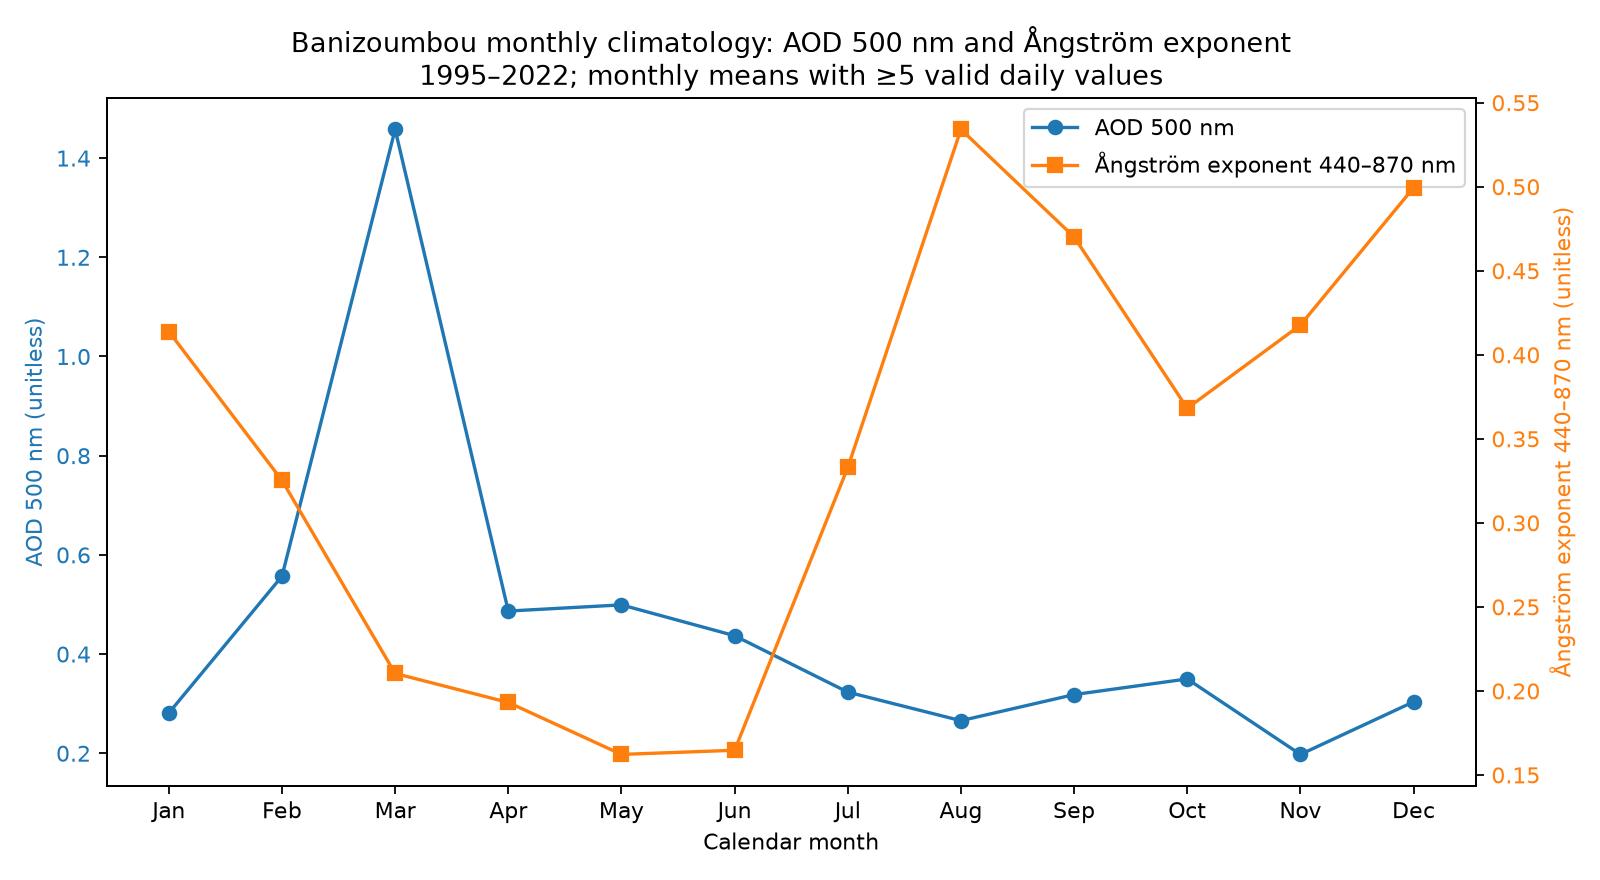


=== KERNEL: kept counts500, summary, pi_summary, annual, clim, pi | deleted Path, site, cols, df, valid_aod, valid_ae, year_cov, m, rows, month, aod_vals, aod_n, ae_vals, ae_n, aod_ok, ae_ok, out, fig, ax1, month_x, aod, ae, ax2, lines, labels, lines2, labels2

=== TURN 3 (ok): 5 model calls, 4 tool calls
    in 37881 (uncached 605, cache read 27360, cache write 9916) | out 2819 (reasoning 363) | $0.0072
=== CONVERSATION: $0.0184
=== KEPT VARIABLES: 2 | [{"name": "clim", "meaning": "Banizoumbou monthly climatology table for AOD 500 nm and \u00c5ngstr\u00f6m exponent 440\u2013870 nm, using >=5 valid daily values per calendar month"}, {"name": "pi", "meaning": "Banizoumbou site PI and email"}]


In [20]:
r = await ask("Show the monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou.")

In [21]:
answer(r)

## Banizoumbou monthly climatology

**Skill used:** `climatology`. The site is **Banizoumbou** (**13.547° N, 2.665° E; elevation 274 m**), with records from **1995-10-16 to 2022-11-25**. I used the measured **AOD 500 nm** and the AERONET-provided **Ångström exponent 440–870 nm**. Values are monthly means, then averaged by calendar month across qualifying years. A calendar month was retained when it had **at least 5 valid daily values**.

| Month | Mean AOD 500 nm | N years (AOD) | Mean Ångström exponent 440–870 nm | N years (AE) |
|---|---:|---:|---:|---:|
| Jan | 0.281 | 1 | 0.41 | 26 |
| Feb | 0.557 | 1 | 0.33 | 26 |
| Mar | 1.458 | 1 | 0.21 | 23 |
| Apr | 0.487 | 2 | 0.19 | 23 |
| May | 0.499 | 2 | 0.16 | 23 |
| Jun | 0.437 | 2 | 0.16 | 23 |
| Jul | 0.323 | 1 | 0.33 | 22 |
| Aug | 0.266 | 1 | 0.53 | 24 |
| Sep | 0.318 | 2 | 0.47 | 25 |
| Oct | 0.350 | 1 | 0.37 | 25 |
| Nov | 0.198 | 2 | 0.42 | 26 |
| Dec | 0.304 | 1 | 0.50 | 25 |

The **Ångström exponent** has 6,581 valid daily values across the record, and every month-of-year has qualifying months. However, **AOD 500 nm is measured on only 362 days**, concentrated in 2021–2022; consequently, each AOD monthly climatology is based on only **one or two years** and is not a robust multi-year seasonal climatology. The AOD values should therefore be interpreted as the available 500 nm record, not as a representative 1995–2022 climatology. Missing days and unmeasured wavelengths are not treated as zero.

The plot is saved as **`/workspace/banizoumbou_monthly_climatology_aod500_ae.png`**. The full table, including medians, 10th/90th percentiles, and qualifying-year counts, is saved as **`/workspace/banizoumbou_monthly_climatology_aod500_ae.csv`**.

**Site PI acknowledgement:** Jean-Louis Rajot (Banizoumbou).

In [22]:
sb.state(CONVERSATION_ID)

{'vars': {'counts500': 'Series(5,)',
  'summary': 'DataFrame(5, 6)[AERONET_Site_Name, lat, lon, first_valid, last_valid, AOD500_days]',
  'pi_summary': 'Series(5,)',
  'annual': 'DataFrame(29, 6)[year, AOD500_mean, valid_months, valid_days, raw_daily_mean, raw_days]',
  'clim': 'DataFrame(12, 12)[month, month_name, AOD500_mean, AOD500_median, AOD500_p10, AOD500_p90, AOD500_years, AE440_870_mean, ... 12 columns]',
  'pi': 'DataFrame(1, 2)[PI, PI_Email]'},
 'files': ['banizoumbou_monthly_climatology_aod500_ae.csv',
  'banizoumbou_monthly_climatology_aod500_ae.png',
  'mauna_loa_annual_aod500.csv'],
 'workspace_mb': 0.14,
 'workspace_cap_mb': 1000,
 'rss_mb': 669,
 'memory_limit_mb': 2147}

In [23]:
variable_meanings()

{'summary': 'Top five sites ranked by valid AOD 500 nm daily count, with coordinates and valid-data periods',
 'pi_summary': 'PI names for the five ranked sites',
 'counts500': 'Valid AOD 500 nm day counts for the top five sites',
 'annual': 'Mauna_Loa annual AOD 500 nm means using >=5 valid days per month and >=9 qualifying months per year; 1997–2025',
 'clim': 'Banizoumbou monthly climatology table for AOD 500 nm and Ångström exponent 440–870 nm, using >=5 valid daily values per calendar month',
 'pi': 'Banizoumbou site PI and email'}

In [24]:
show_turns()

,turn,asked,status,question,summary,variables,sandbox,restart_note,requests,tool_calls,input_tokens,uncached_input,cache_read,cache_write,output_tokens,reasoning_tokens,cost_usd
0,1,2026-09-29T17:39:35+00:00,ok,Which five sites have the longest AOD 500 nm r...,"tools: list_sites×1, describe_columns×5, run_p...","[{""name"": ""summary"", ""meaning"": ""Top five site...",8bd15e49f45d,None,6,9,52598,726,40019,11853,1913,496,0.006825
1,2,2026-09-29T17:41:51+00:00,ok,"For the top one of those, what is its mean AOD...",tools: run_python×1 | files: mauna_loa_annual_...,"[{""name"": ""annual"", ""meaning"": ""Mauna_Loa annu...",8bd15e49f45d,None,2,1,11568,242,4638,6688,1825,371,0.004403
2,3,2026-09-29T17:48:43+00:00,ok,Show the monthly climatology of AOD 500 nm and...,"tools: list_sites×1, describe_columns×1, run_p...","[{""name"": ""clim"", ""meaning"": ""Banizoumbou mont...",8bd15e49f45d,None,5,4,37881,605,27360,9916,2819,363,0.007183


In [26]:
sb.stop(CONVERSATION_ID)      # stands in for 60 idle minutes: variables gone, files kept

In [28]:
r = await ask("What do we have so far, and what is left in the sandbox?")

=== What do we have so far, and what is left in the sandbox?
    (3 earlier turns in context; conversation so far $0.0184)

--- step 1: to model
  >>> USER        : ### sandbox state now
kernel: restarted (no reason recorded: memory limit, host restart or stopped by hand); every earlier variable is gone, files in /workspace are kept
variables: none
memory used: 201 of 2147 MB; storage used: 0.14 of 1000 MB in /workspace

### question
What do we have so far, and what is left in the sandbox?
--- step 1: from model
  ... THINKING    : <no text>
  <<< PREAMBLE    : I’ll inspect the restarted sandbox state and list the files that survived, so I can separate reusable outputs from variables that were lost.
  --> TOOL CALL   : kernel_state({})
      in 6203 (uncached 121, cache read 0, cache write 6082) | out 72 (reasoning 23) | $0.0018

--- step 2: to model
  <-- TOOL RESULT : kernel_state -> {
 "vars": {},
 "files": [
  "banizoumbou_monthly_climatology_aod500_ae.csv",
  "banizoumbou_monthly_

In [29]:
answer(r)

## Sandbox inventory

The kernel **restarted**, so there are currently **no in-memory variables** to reuse. The source AERONET parquet remains available for rebuilding analyses through the sandbox tools.

### Results completed so far

1. **Longest AOD 500 nm records**
   - Identified the five sites with the most valid daily AOD 500 nm observations.
   - The ranking and counts were reported in the conversation.
   - No output file was saved for that ranking.

2. **Mauna_Loa annual AOD 500 nm**
   - Site: Mauna_Loa, 19.536° N, 155.577° W.
   - Used the climatology rule of at least 5 valid days per month and at least 9 qualifying months per year.
   - Saved file: `mauna_loa_annual_aod500.csv`

3. **Banizoumbou monthly climatology**
   - Site: Banizoumbou, 13.547° N, 2.665° E.
   - Produced monthly climatologies for AOD 500 nm and Ångström exponent 440–870 nm.
   - Saved files:
     - `banizoumbou_monthly_climatology_aod500_ae.csv`
     - `banizoumbou_monthly_climatology_aod500_ae.png`
   - The previous analysis noted that AOD 500 nm coverage was sparse—362 valid days concentrated in 2021–2022—so its monthly climatology was based on only one or two years per month and was not a robust multi-year seasonal climatology.

### What remains in the sandbox

- **Workspace files:** the three files listed above; workspace usage is approximately **0.14 MB of 1,000 MB**.
- **Memory:** approximately **201 MB of 2,147 MB** is in use.
- **Kernel variables:** none.
- **Reusable data:** no loaded DataFrames or intermediate objects survived. Any new analysis must reload the required columns from the AERONET parquet and repeat site discovery/column checks as needed.

The saved CSVs and PNG survive the restart; the prior conversation remains available as context, but its temporary Python objects do not.

## 10 · Check the tokens

Every model response in the stored trace carries its own usage. `calls_table(turn)` lists them one call per row and
adds them up; `check_tokens(turn)` compares that sum with the turn's row in the table. They must be equal. When a
later step makes model calls outside the agent loop (e.g. looking at a figure), this is the check that they were
counted.

In [30]:
TOKEN_COLUMNS = ["input_tokens", "uncached_input", "cache_read", "cache_write", "output_tokens", "reasoning_tokens"]


def load_messages(turn):
    row = all_turns()[turn - 1]
    return ModelMessagesTypeAdapter.validate_json(row["messages"])


def calls_table(turn):
    """One row per model call of a stored turn, read from its trace."""
    rows = []
    for message in load_messages(turn):
        if isinstance(message, ModelResponse):
            columns = token_columns(message.usage)          # same arithmetic as the stored row
            rows.append({c: columns[c] for c in TOKEN_COLUMNS + ["cost_usd"]})
    return pd.DataFrame(rows, index=pd.RangeIndex(1, len(rows) + 1, name="call"))


def check_tokens(turn):
    """Add up the model calls of a stored turn and compare with the numbers in its row."""
    calls  = calls_table(turn)
    stored = all_turns()[turn - 1]
    for c in TOKEN_COLUMNS + ["cost_usd"]:
        summed = sum(v or 0 for v in calls[c])              # None (not reported) counts as 0
        verdict = "ok" if abs(summed - (stored[c] or 0)) < 1e-9 else "MISMATCH"
        print(f"  {c:17} sum of {len(calls)} calls: {summed:>10.6g}   stored: {stored[c]!s:>10}   {verdict}")

In [31]:
calls_table(1)

,input_tokens,uncached_input,cache_read,cache_write,output_tokens,reasoning_tokens,cost_usd
call,,,,,,,
1,4173,121,0,4052,93,40,0.001264
2,5062,121,4052,889,199,59,0.000623
3,9697,121,4941,4635,288,95,0.001790
4,10199,121,9576,502,423,121,0.000934
5,11493,121,10078,1294,227,74,0.000904
6,11974,121,11372,481,683,107,0.001311


In [32]:
check_tokens(1)

  input_tokens      sum of 6 calls:      52598   stored:      52598   ok
  uncached_input    sum of 6 calls:        726   stored:        726   ok
  cache_read        sum of 6 calls:      40019   stored:      40019   ok
  cache_write       sum of 6 calls:      11853   stored:      11853   ok
  output_tokens     sum of 6 calls:       1913   stored:       1913   ok
  reasoning_tokens  sum of 6 calls:        496   stored:        496   ok
  cost_usd          sum of 6 calls: 0.00682487   stored: 0.006824873   ok


## 11 · Resume tomorrow

Nothing to save: SQLite already has every turn. After reopening the notebook:

1. Run sections 1–8 with the same `CONVERSATION_ID`. Nothing is loaded into Python: every function reads the
   SQLite file when it is called.
2. `preview_context()` shows what the next question will get: the last `KEEP_TURNS` finished turns from the file,
   and a state block from the sandbox. The container stopped itself after 60 idle minutes, so section 2 starts a
   new one (new id ≠ id of the last turn) and the block says *restarted*, with no variables and the files of the last 5 turns.
3. `await ask(...)` as usual. The model can reload what it needs from the files the earlier answers name.

Same thing as the `sb.stop` in section 9. The only difference is that the notebook itself was closed as well.

In [33]:
show_turns()

,turn,asked,status,question,summary,variables,sandbox,restart_note,requests,tool_calls,input_tokens,uncached_input,cache_read,cache_write,output_tokens,reasoning_tokens,cost_usd
0,1,2026-09-29T17:39:35+00:00,ok,Which five sites have the longest AOD 500 nm r...,"tools: list_sites×1, describe_columns×5, run_p...","[{""name"": ""summary"", ""meaning"": ""Top five site...",8bd15e49f45d,NaN,6,9,52598,726,40019,11853,1913,496,0.006825
1,2,2026-09-29T17:41:51+00:00,ok,"For the top one of those, what is its mean AOD...",tools: run_python×1 | files: mauna_loa_annual_...,"[{""name"": ""annual"", ""meaning"": ""Mauna_Loa annu...",8bd15e49f45d,NaN,2,1,11568,242,4638,6688,1825,371,0.004403
2,3,2026-09-29T17:48:43+00:00,ok,Show the monthly climatology of AOD 500 nm and...,"tools: list_sites×1, describe_columns×1, run_p...","[{""name"": ""clim"", ""meaning"": ""Banizoumbou mont...",8bd15e49f45d,NaN,5,4,37881,605,27360,9916,2819,363,0.007183
3,4,2026-09-29T17:51:00+00:00,ok,"What do we have so far, and what is left in th...",tools: kernel_state×1,[],a7557669eccf,"restarted (no reason recorded: memory limit, h...",2,1,12583,242,6082,6259,896,299,0.003091


In [34]:
preview_context()

--- USER : Which five sites have the longest AOD 500 nm records, and how many days of data does each have?

--- MODEL: ## Five longest AOD 500 nm records

**Skill used:** `data_access`. I ranked all sites by the number of non-missing **AOD 500 nm** daily values. No minimum-coverage threshold was imposed; missing values were not counted as zero.

| Rank | Site | Latitude (°) | Longitude (°) | Period of valid AOD 500 nm | N valid days |
|---:|---|---:|---:|---|---:|
| 1 | Mauna_Loa | 19.536 | −155.577 | 1995-03-16 to 2026-07-07 | 9,152 |
| 2 | GSFC | 38.993 | −76.840 | 1995-03-24 to 2026-01-08 | 7,973 |
| 3 | SEDE_BOKER | 30.855 | 34.782 | 1997-09-25 to 2025-04-04 | 7,706 |
| 4 | Izana | 28.309 | −16.499 | 1997-06-15 to 2026-01-27 | 6,375 |
| 5 | Sevilleta | 34.355 | −106.885 | 1995-07-06 to 2025-03-26 | 6,204 |

**Wavelength:** AOD 500 nm, unitless. **N:** valid daily observations, where each row is an AERONET Level 2.0 daily mean stamped at 12:00 UTC. The date ranges are the first and 

In [35]:
# the full trace of one turn, message by message
for message in load_messages(1):
    for p in message.parts:
        show_part(p)

  >>> USER        : ### sandbox state now
variables: none
memory used: 200 of 2147 MB; storage used: 0.0 of 1000 MB in /workspace

### question
Which five sites have the longest AOD 500 nm records, and how many days of data does each have?
  ... THINKING    : <no text>
  <<< ANSWER      : I’ll first identify the longest-record sites and their exact names and coordinates, then verify 500 nm coverage for the leading candidates.
  --> TOOL CALL   : list_sites({"limit":20})
  <-- TOOL RESULT : list_sites -> 1485 site(s) match, showing the 20 with the longest records
                        lat      lon  elev_m       first        last  days
AERONET_Site_Name                                                         
Mauna_Loa            19.536 -155.577    3402  1994-06-03  2026-07-07  9198
GSFC                 38.992  -76.840      87  1993-05-14  2026-01-08  8234
SEDE_BOKER           30.855   34.782     480  1995-08-11  2025-04-04  7767
Ispra                45.803    8.627     235  1997-06-28

## 12 · Cleanup

In [36]:
sb.stop(CONVERSATION_ID)